In [14]:
%pip install matplotlib

%pip install seaborn

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [15]:
# Setup - run this cell first

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

plt.rcParams['figure.dpi'] = 110

sns.set_theme(style='whitegrid')

print('Libraries loaded successfully')

Libraries loaded successfully


In [16]:
# Load your dataset here

df = pd.read_excel('taxis_data.xlsx')

# 1. Print shape
print('Shape of the dataset:', df.shape)

# 2. Show first rows
print('\nFirst 5 rows of the dataset:')
print(df.head())

Shape of the dataset: (6433, 14)

First 5 rows of the dataset:
               pickup             dropoff  passengers  distance  fare   tip  \
0 2019-03-23 20:21:09 2019-03-23 20:27:24           1      1.60   7.0  2.15   
1 2019-03-04 16:11:55 2019-03-04 16:19:00           1      0.79   5.0  0.00   
2 2019-03-27 17:53:01 2019-03-27 18:00:25           1      1.37   7.5  2.36   
3 2019-03-10 01:23:59 2019-03-10 01:49:51           1      7.70  27.0  6.15   
4 2019-03-30 13:27:42 2019-03-30 13:37:14           3      2.16   9.0  1.10   

   tolls  total   color      payment            pickup_zone  \
0    0.0  12.95  yellow  credit card        Lenox Hill West   
1    0.0   9.30  yellow         cash  Upper West Side South   
2    0.0  14.16  yellow  credit card          Alphabet City   
3    0.0  36.95  yellow  credit card              Hudson Sq   
4    0.0  13.40  yellow  credit card           Midtown East   

            dropoff_zone pickup_borough dropoff_borough  
0    UN/Turtle Bay South 

In [17]:
# 3. Structural info

print('\nDataset info:')
df.info()


Dataset info:
<class 'pandas.DataFrame'>
RangeIndex: 6433 entries, 0 to 6432
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   pickup           6433 non-null   datetime64[us]
 1   dropoff          6433 non-null   datetime64[us]
 2   passengers       6433 non-null   int64         
 3   distance         6433 non-null   float64       
 4   fare             6433 non-null   float64       
 5   tip              6433 non-null   float64       
 6   tolls            6433 non-null   float64       
 7   total            6433 non-null   float64       
 8   color            6433 non-null   str           
 9   payment          6389 non-null   str           
 10  pickup_zone      6407 non-null   str           
 11  dropoff_zone     6388 non-null   str           
 12  pickup_borough   6407 non-null   str           
 13  dropoff_borough  6388 non-null   str           
dtypes: datetime64[us](2), float64(5), in

In [18]:
# 4. Numeric summary

print('\nNumeric summary:')
df.describe()


Numeric summary:


,pickup,dropoff,passengers,distance,fare,tip,tolls,total
count,6433,6433,6433.000000,6433.000000,6433.000000,6433.00000,6433.000000,6433.000000
mean,2019-03-16 08:31:28.514223,2019-03-16 08:45:49.491216,1.539251,3.024617,13.091073,1.97922,0.325273,18.517794
min,2019-02-28 23:29:03,2019-02-28 23:32:35,0.000000,0.000000,1.000000,0.00000,0.000000,1.300000
25%,2019-03-08 15:50:34,2019-03-08 16:12:51,1.000000,0.980000,6.500000,0.00000,0.000000,10.800000
50%,2019-03-15 21:46:58,2019-03-15 22:06:44,1.000000,1.640000,9.500000,1.70000,0.000000,14.160000
75%,2019-03-23 17:41:38,2019-03-23 17:51:56,2.000000,3.210000,15.000000,2.80000,0.000000,20.300000
max,2019-03-31 23:43:45,2019-04-01 00:13:58,6.000000,36.700000,150.000000,33.20000,24.020000,174.820000
std,NaN,NaN,1.203768,3.827867,11.551804,2.44856,1.415267,13.815570


In [19]:
print('Shape before cleaning:', df.shape)

Shape before cleaning: (6433, 14)


In [20]:

# Step 1 Inspect missing values

print('\nMissing values :')

print(df.isna())


Missing values :
      pickup  dropoff  passengers  distance   fare    tip  tolls  total  \
0      False    False       False     False  False  False  False  False   
1      False    False       False     False  False  False  False  False   
2      False    False       False     False  False  False  False  False   
3      False    False       False     False  False  False  False  False   
4      False    False       False     False  False  False  False  False   
...      ...      ...         ...       ...    ...    ...    ...    ...   
6428   False    False       False     False  False  False  False  False   
6429   False    False       False     False  False  False  False  False   
6430   False    False       False     False  False  False  False  False   
6431   False    False       False     False  False  False  False  False   
6432   False    False       False     False  False  False  False  False   

      color  payment  pickup_zone  dropoff_zone  pickup_borough  \
0     False   

In [21]:

# Count missing values

print('\nCount of missing values per column:')

print(df.isnull().sum())


Count of missing values per column:
pickup              0
dropoff             0
passengers          0
distance            0
fare                0
tip                 0
tolls               0
total               0
color               0
payment            44
pickup_zone        26
dropoff_zone       45
pickup_borough     26
dropoff_borough    45
dtype: int64


In [22]:
#Step 2 Handle missing values (fillna / dropna)

df.loc[df['payment'].isna(), 'payment'] = df['payment'].mode()[0]


In [23]:
# Drop rows with any remaining missing values

df.dropna(inplace=True)

In [24]:

# Step 3 Drop irrelevant columns

df.drop(columns=['color'], inplace=True)

In [25]:
# Step 4
# Engineer at least 1 new feature

# trip_duration = dropoff - pickup (in minutes)
df['trip_duration'] = (df['dropoff'] - df['pickup']).dt.total_seconds() / 60 #convert to minutes

In [26]:
df.head()

,pickup,dropoff,passengers,distance,fare,tip,tolls,total,payment,pickup_zone,dropoff_zone,pickup_borough,dropoff_borough,trip_duration
0,2019-03-23 20:21:09,2019-03-23 20:27:24,1,1.60,7.0,2.15,0.0,12.95,credit card,Lenox Hill West,UN/Turtle Bay South,Manhattan,Manhattan,6.250000
1,2019-03-04 16:11:55,2019-03-04 16:19:00,1,0.79,5.0,0.00,0.0,9.30,cash,Upper West Side South,Upper West Side South,Manhattan,Manhattan,7.083333
2,2019-03-27 17:53:01,2019-03-27 18:00:25,1,1.37,7.5,2.36,0.0,14.16,credit card,Alphabet City,West Village,Manhattan,Manhattan,7.400000
3,2019-03-10 01:23:59,2019-03-10 01:49:51,1,7.70,27.0,6.15,0.0,36.95,credit card,Hudson Sq,Yorkville West,Manhattan,Manhattan,25.866667
4,2019-03-30 13:27:42,2019-03-30 13:37:14,3,2.16,9.0,1.10,0.0,13.40,credit card,Midtown East,Yorkville West,Manhattan,Manhattan,9.533333


In [27]:
# NumPy calculations

avg_fare = np.mean(df['fare'])
print(f'Average fare: {avg_fare:.2f}')

max_distance = np.max(df['distance'])
min_distance = np.min(df['distance'])

print(f'Max distance: {max_distance:.2f}')
print(f'Min distance: {min_distance:.2f}')

total_earnings = np.sum(df['total'])
print(f'Total earnings: {total_earnings:.2f}')

Average fare: 12.87
Max distance: 36.70
Min distance: 0.00
Total earnings: 116688.00


In [28]:
# GroupBy aggregation

result = df.groupby('payment')['fare'].mean()

print('\nAverage fare by payment type:')
print(result)


Average fare by payment type:
payment
cash           11.259053
credit card    13.505094
Name: fare, dtype: float64


In [29]:
# Pivot table or crosstab

pivot = pd.pivot_table(df, values='tip', index='payment', aggfunc='sum')

print('\nTotal tips by payment type:')
print(pivot)


Total tips by payment type:
                  tip
payment              
cash             0.00
credit card  12508.91


In [31]:
# Passenger count vs payment method (cross-tabulation)

cross = pd.crosstab(df['passengers'], df['payment'])

print('\nPassenger count vs Payment method:')
print(cross)


Passenger count vs Payment method:
payment     cash  credit card
passengers                   
0             13           83
1           1299         3339
2            260          610
3             78          162
4             29           81
5             78          199
6             38          114


In [32]:
# Formatted summary (use f-strings or print statements)

avg_fare = df['fare'].mean()
total_trips = len(df)

print(f'\nThe average fare across all trips is ${avg_fare:.2f}.')
print(f'The total number of trips in the dataset is {total_trips}.')


The average fare across all trips is $12.87.
The total number of trips in the dataset is 6383.


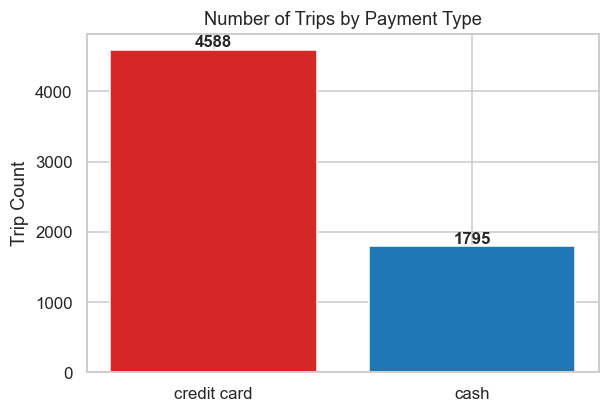

In [40]:
trip_counts = df['payment'].value_counts()

fig, ax = plt.subplots(figsize=(6, 4))

bars = ax.bar(trip_counts.index, trip_counts.values, color=['tab:red', 'tab:blue'])

for bar, val in zip(bars, trip_counts.values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{val}",
        ha='center',
        va='bottom',
        fontsize=11,
        fontweight='bold'
    )

ax.set_title('Number of Trips by Payment Type')
ax.set_ylabel('Trip Count')

plt.show()

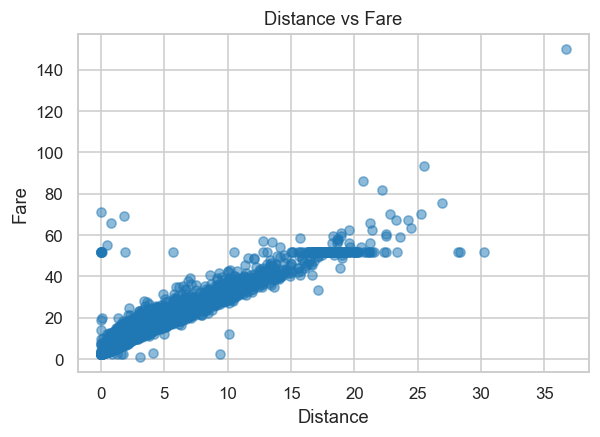

In [41]:
# Scatter Plot

fig, ax = plt.subplots(figsize=(6, 4))

ax.scatter(df['distance'], df['fare'], alpha=0.5, color='tab:blue')

ax.set_title('Distance vs Fare')
ax.set_xlabel('Distance')
ax.set_ylabel('Fare')

plt.show()

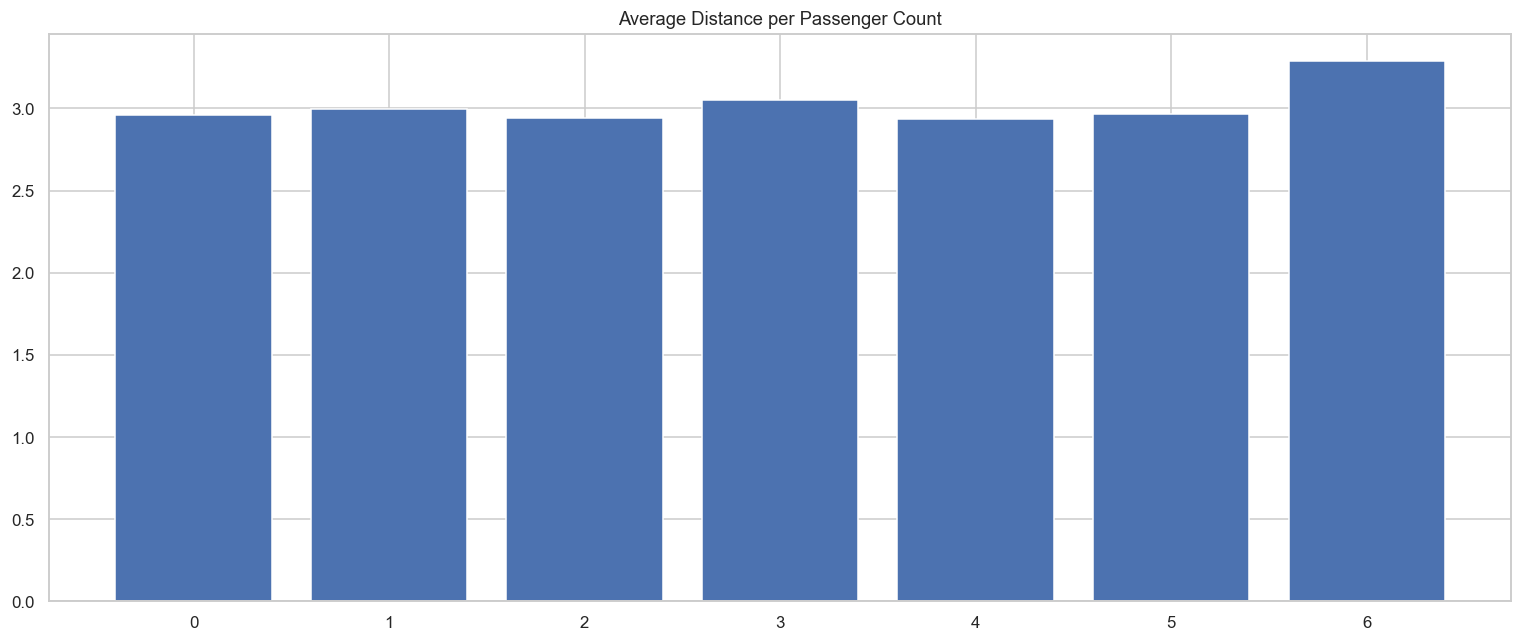

In [47]:
#  Average Distance by Passenger Count
#  Group data by number of passengers and calculate average distance
distance_stats = df.groupby('passengers')['distance'].mean()

# Create figure and axis with specified size
fig, ax = plt.subplots(figsize=(14, 6))

# Plot bar chart of average distance per passenger count
bars = ax.bar(distance_stats.index, distance_stats.values)

ax.set_title('Average Distance per Passenger Count')

# Adjust layout to avoid overlap
plt.tight_layout()
plt.show()

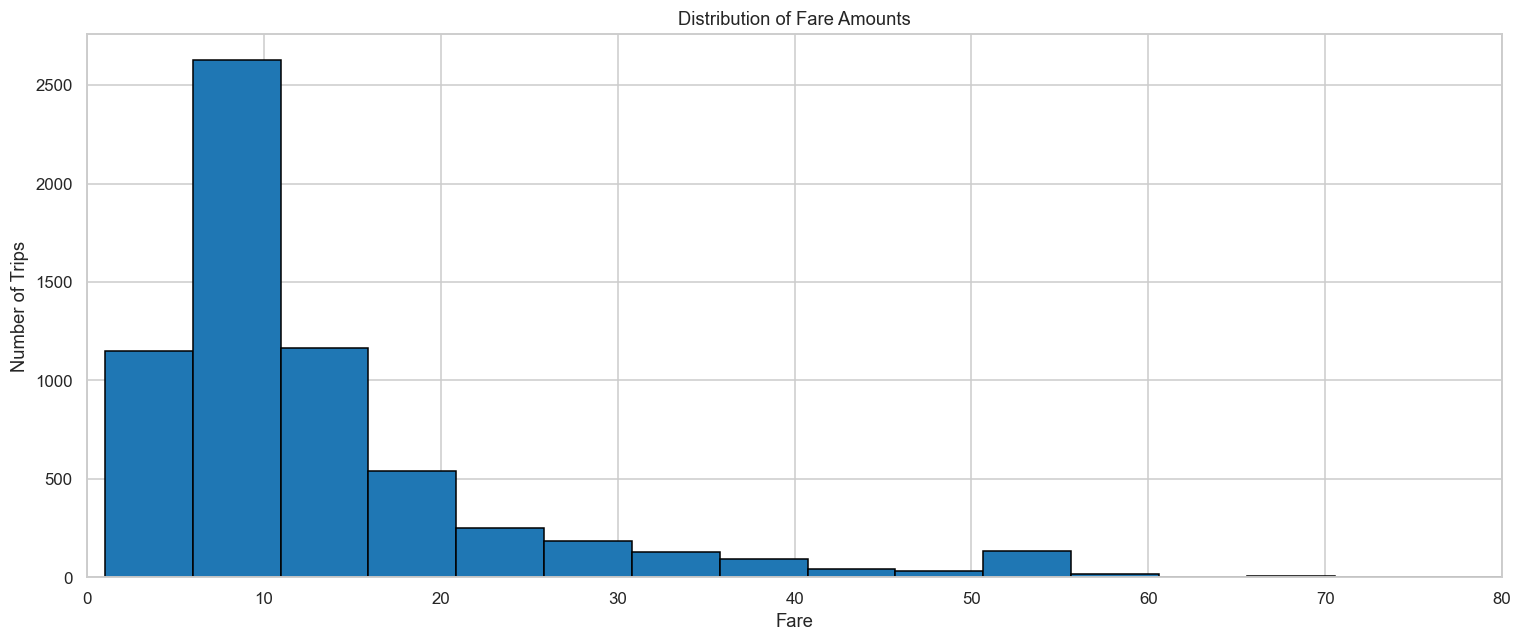

In [50]:
# Histogram of fare distribution

fig, ax = plt.subplots(figsize=(14, 6))

# Plot histogram for fare
ax.hist(df['fare'], bins=30, color='tab:blue', edgecolor='black')

# Set title and labels
ax.set_title('Distribution of Fare Amounts')
ax.set_xlabel('Fare')
ax.set_ylabel('Number of Trips')

# Limit x-axis to 0–100
ax.set_xlim(0, 80)

plt.tight_layout()
plt.show()